# Cacería y pesca

# Librerías

In [4]:
library(ggplot2)
library(dplyr)
library(lubridate)
library(bslib)
source("Functions/plot_themes.R")
library(stringr)
library(plotly)
library(tidyr)
library(htmlwidgets)
library(dygraphs)
library(xts)
library(tidyverse)
library(googleVis)
library(scales)
library(tidytext)
library(igraph)
library(ggraph)
library(wordcloud)

Need help? Try Stackoverflow: https://stackoverflow.com/tags/ggplot2

Attaching package: ‘dplyr’

The following objects are masked from ‘package:stats’:

    filter, lag

The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Attaching package: ‘lubridate’

The following objects are masked from ‘package:base’:

    date, intersect, setdiff, union


Attaching package: ‘bslib’

The following object is masked from ‘package:utils’:

    page


Attaching package: ‘plotly’

The following object is masked from ‘package:ggplot2’:

    last_plot

The following object is masked from ‘package:stats’:

    filter

The following object is masked from ‘package:graphics’:

    layout



Warning message:
package ‘htmlwidgets’ was built under R version 4.4.3 
Warning message:
package ‘dygraphs’ was built under R version 4.4.3 


Loading required package: zoo

Attaching package: ‘zoo’

The following objects are masked from ‘package:base’:

    as.Date, as.Date.numeric


######################### Warning from 'xts' package ##########################
#                                                                             #
# The dplyr lag() function breaks how base R's lag() function is supposed to  #
# work, which breaks lag(my_xts). Calls to lag(my_xts) that you type or       #
# source() into this session won't work correctly.                            #
#                                                                             #
# Use stats::lag() to make sure you're not using dplyr::lag(), or you can add #
# conflictRules('dplyr', exclude = 'lag') to your .Rprofile to stop           #
# dplyr from breaking base R's lag() function.                                #
#                                                                             #
# Code in packages is not affected. It's protected by R's

Warning messages:
1: package ‘xts’ was built under R version 4.4.3 
2: package ‘zoo’ was built under R version 4.4.3 


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ forcats 1.0.0     ✔ readr   2.2.0
✔ purrr   1.0.2     ✔ tibble  3.3.1
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ plotly::filter() masks dplyr::filter(), stats::filter()
✖ xts::first()     masks dplyr::first()
✖ dplyr::lag()     masks stats::lag()
✖ xts::last()      masks dplyr::last()
ℹ Use the ]8;;http://conflicted.r-lib.org/conflicted package]8;; to force all conflicts to become errors


...

Warning message:
package ‘tidytext’ was built under R version 4.4.3 



Attaching package: ‘igraph’

The following objects are masked from ‘package:purrr’:

    compose, simplify

The following object is masked from ‘package:tibble’:

    as_data_frame

The following object is masked from ‘package:tidyr’:

    crossing

The following object is masked from ‘package:plotly’:

    groups

The following objects are masked from ‘package:lubridate’:

    %--%, union

The following objects are masked from ‘package:dplyr’:

    as_data_frame, groups, union

The following objects are masked from ‘package:stats’:

    decompose, spectrum

The following object is masked from ‘package:base’:

    union



Warning message:
package ‘igraph’ was built under R version 4.4.3 
Warning message:
package ‘ggraph’ was built under R version 4.4.3 


Loading required package: RColorBrewer


Warning message:
package ‘wordcloud’ was built under R version 4.4.3 


# Carga de datos

In [1]:
caceria_pesca= read.csv("../Data/Reporte_cacería_pesca.csv")
caceria_pesca$Fecha = as.Date(caceria_pesca$Fecha, format = "%Y-%m-%d")

# Análisis de datos

In [7]:
head(caceria_pesca)

  X      X_id                               X_uuid           X__version__
1 0 443814013 27beb75c-f6ed-4a64-b789-a643f6a8cad4 vaixYx97CTWbPsFJAg2ZUu
2 1 447961711 10a0e2cd-d6b5-4925-b546-3fdce9f289a5 vaixYx97CTWbPsFJAg2ZUu
3 2 448081438 5518a533-ba1f-41cf-adeb-2f1ac5edeb72 vaixYx97CTWbPsFJAg2ZUu
4 3 448081639 4d89b121-1a18-47cd-a0d7-7e385901b2ed vaixYx97CTWbPsFJAg2ZUu
5 4 448081748 3e26e05c-d877-48be-b205-6782f8c62d64 vaixYx97CTWbPsFJAg2ZUu
6 5 448081748 3e26e05c-d877-48be-b205-6782f8c62d64 vaixYx97CTWbPsFJAg2ZUu
    X_submission_time X_validation_status  timestamp           X_submitted_by
1 2025-02-21T18:44:15            Approved 1741706801 conservacion_sharamentsa
2 2025-03-04T13:03:54            Approved 1753051535 conservacion_sharamentsa
3 2025-03-04T17:57:08            Approved 1753051654 conservacion_sharamentsa
4 2025-03-04T17:58:04            Approved 1753051787 conservacion_sharamentsa
5 2025-03-04T17:58:29            Approved 1753051859 conservacion_sharamentsa
6 2025-03-04T1

## Distribución cacería y pesca

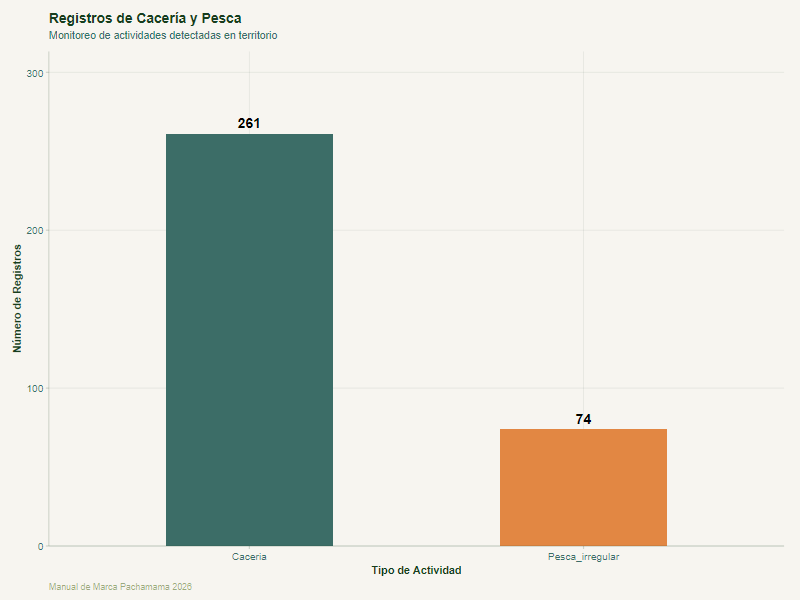

In [6]:

# 1. Preparar los datos: Contar frecuencias de actividades
resumen_actividades <- caceria_pesca %>%
  group_by(Tipo_actividad) %>%
  summarise(Conteo = n(), .groups = 'drop') %>%
  # Limpieza de posibles NAs o textos vacíos
  filter(!is.na(Tipo_actividad) & Tipo_actividad != "")

# 2. Generar la gráfica de barras
ggplot(resumen_actividades, aes(x = reorder(Tipo_actividad, -Conteo), y = Conteo, fill = Tipo_actividad)) +
  geom_col(width = 0.5, show.legend = FALSE) +
  # Etiquetas de valor sobre las barras para lectura inmediata
  geom_text(aes(label = Conteo), vjust = -0.5, fontface = "bold", size = 5) +
  # Colores específicos para distinguir cacería de pesca
  scale_fill_manual(values = c("Caceria" = "#3c6d67", "Pesca_irregular" = "#e28743")) +
  labs(
    title = "Registros de Cacería y Pesca",
    subtitle = "Monitoreo de actividades detectadas en territorio",
    x = "Tipo de Actividad",
    y = "Número de Registros",
    caption = "Manual de Marca Pachamama 2026"
  ) +
  # Espacio superior para que la etiqueta no se corte
  scale_y_continuous(expand = expansion(mult = c(0, 0.2))) +
  theme_pachamama()

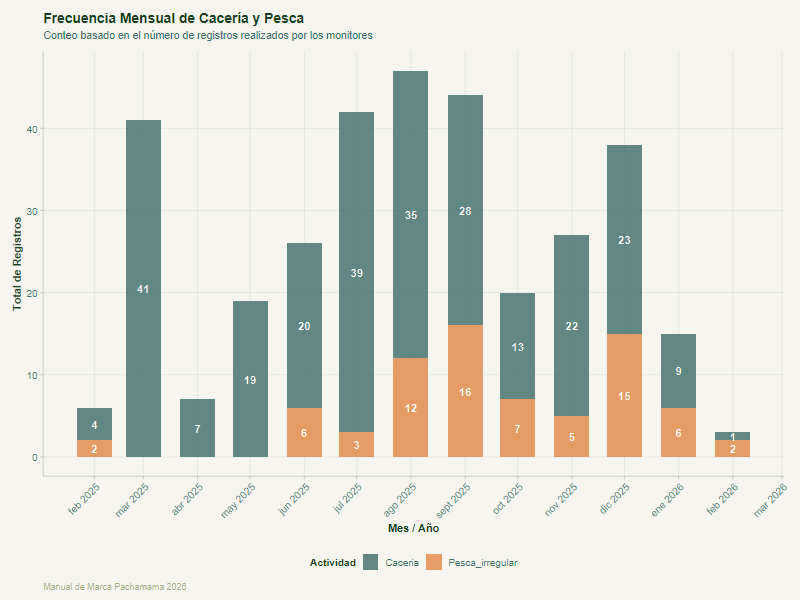

In [9]:


# 1. Preparar los datos: Conteo de registros (filas) por mes y actividad
caceria_conteo_mensual <- caceria_pesca %>%
  mutate(
    # Aseguramos que la fecha sea reconocida y agrupamos por mes
    Mes = floor_date(as.Date(Fecha), "month")
  ) %>%
  group_by(Mes, Tipo_actividad) %>%
  summarise(Numero_Registros = n(), .groups = 'drop') # n() cuenta cada fila como 1

# 2. Generar la gráfica de barras apiladas en el tiempo
ggplot(caceria_conteo_mensual, aes(x = Mes, y = Numero_Registros, fill = Tipo_actividad)) +
  # Barras con ancho ajustado para que se vean bien en serie de tiempo
  geom_col(alpha = 0.8, width = 20, position = "stack") + 
  # Etiquetas de valor sobre cada segmento de la barra
  geom_text(aes(label = Numero_Registros), 
            position = position_stack(vjust = 0.5), 
            color = "white", fontface = "bold", size = 4) +
  # Colores de la paleta Pachamama
  scale_fill_manual(values = c("Caceria" = "#3c6d67", "Pesca_irregular" = "#e28743")) +
  # Formateo del eje X
  scale_x_date(date_labels = "%b %Y", date_breaks = "1 month") +
  labs(
    title = "Frecuencia Mensual de Cacería y Pesca",
    subtitle = "Conteo basado en el número de registros realizados por los monitores",
    x = "Mes / Año",
    y = "Total de Registros",
    fill = "Actividad",
    caption = "Manual de Marca Pachamama 2026"
  ) +
  theme_pachamama() +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1),
    legend.position = "bottom"
  )

In [17]:
caceria_pesca

    X      X_id                               X_uuid           X__version__
1   0 443814013 27beb75c-f6ed-4a64-b789-a643f6a8cad4 vaixYx97CTWbPsFJAg2ZUu
2   1 447961711 10a0e2cd-d6b5-4925-b546-3fdce9f289a5 vaixYx97CTWbPsFJAg2ZUu
3   2 448081438 5518a533-ba1f-41cf-adeb-2f1ac5edeb72 vaixYx97CTWbPsFJAg2ZUu
4   3 448081639 4d89b121-1a18-47cd-a0d7-7e385901b2ed vaixYx97CTWbPsFJAg2ZUu
5   4 448081748 3e26e05c-d877-48be-b205-6782f8c62d64 vaixYx97CTWbPsFJAg2ZUu
6   5 448081748 3e26e05c-d877-48be-b205-6782f8c62d64 vaixYx97CTWbPsFJAg2ZUu
7   6 448081748 3e26e05c-d877-48be-b205-6782f8c62d64 vaixYx97CTWbPsFJAg2ZUu
8   7 448081798 b8bb9cae-1c9e-4324-96f6-1a378eb457e6 vaixYx97CTWbPsFJAg2ZUu
9   8 448122205 d151bbb7-8d63-48d1-aa0f-f61cef942731 vaixYx97CTWbPsFJAg2ZUu
10  9 448122205 d151bbb7-8d63-48d1-aa0f-f61cef942731 vaixYx97CTWbPsFJAg2ZUu
11 10 448422878 f90e0dff-d508-43bf-ada6-e12457692a43 vaixYx97CTWbPsFJAg2ZUu
12 11 448422878 f90e0dff-d508-43bf-ada6-e12457692a43 vaixYx97CTWbPsFJAg2ZUu
13 12 448422

In [23]:
library(dplyr)
library(googleVis)
library(tidyr)

# 1. Preparar y limpiar los datos para el flujo de 3 niveles
caceria_pesca_ordenado <- caceria_pesca %>%
  mutate(
    # Renombrar Pesca_irregular a Pesca
    Tipo_actividad = if_else(Tipo_actividad == "Pesca_irregular", "Pesca", Tipo_actividad),
    # Asegurar que no haya vacíos en las categorías clave
    Quien_realizo = replace_na(Quien_realizo, "No registrado"),
    Comunidad = replace_na(Comunidad, "Sin comunidad")
  )

# --- Nivel 1: Quien_realizo -> Tipo_actividad ---
flujo_1 <- caceria_pesca_ordenado %>%
  group_by(Quien_realizo, Tipo_actividad) %>%
  summarise(Weight = n(), .groups = "drop") %>%
  rename(From = Quien_realizo, To = Tipo_actividad)

# --- Nivel 2: Tipo_actividad -> Comunidad ---
flujo_2 <- caceria_pesca_ordenado %>%
  group_by(Tipo_actividad, Comunidad) %>%
  summarise(Weight = n(), .groups = "drop") %>%
  rename(From = Tipo_actividad, To = Comunidad)

# Unir flujos en el nuevo orden lógico
datos_sankey_final <- bind_rows(flujo_1, flujo_2)

# 2. Configuración estética (Colores Pachamama)
colores_js <- paste0("['", paste(as.character(PAL_CUAL), collapse = "', '"), "']")

opts_sankey <- list(
  width = 900, height = 600,
  sankey = paste0("{
    node: { 
      colors: ", colores_js, ",
      label: { fontName: 'Arial', fontSize: 14, color: '#183d1e', bold: true },
      nodePadding: 45,
      interactivity: true
    },
    link: { 
      colorMode: 'gradient',
      colors: ", colores_js, ",
      fillOpacity: 0.25
    }
  }")
)

# 3. Generar y mostrar el Sankey
sankey_pacha_ordenado <- gvisSankey(datos_sankey_final, 
                                    from = "From", 
                                    to = "To", 
                                    weight = "Weight",
                                    options = opts_sankey)

plot(sankey_pacha_ordenado)

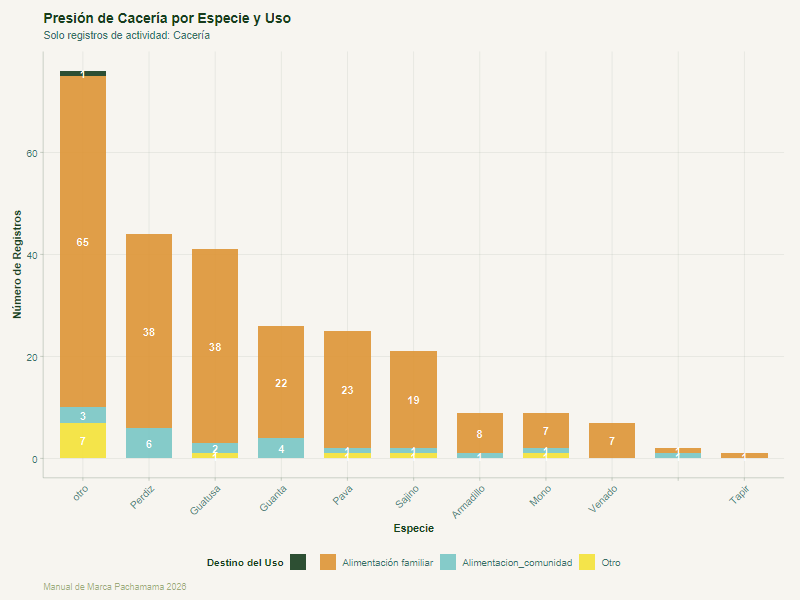

In [24]:

# 1. Filtrar y preparar los datos
caceria_especies_uso <- caceria_pesca %>%
  # Filtramos solo por Cacería
  filter(Tipo_actividad == "Caceria") %>%
  # Limpiamos NAs para que no ensucien la gráfica
  mutate(
    Especie = replace_na(Especie, "No especificado"),
    Uso_caceria = replace_na(Uso_caceria, "Uso no registrado")
  ) %>%
  group_by(Especie, Uso_caceria) %>%
  summarise(Conteo = n(), .groups = 'drop')

# 2. Generar el gráfico de barras apiladas
ggplot(caceria_especies_uso, aes(x = reorder(Especie, -Conteo, sum), y = Conteo, fill = Uso_caceria)) +
  # Barras apiladas
  geom_col(alpha = 0.9, width = 0.7) +
  # Etiquetas de valor sobre cada segmento
  geom_text(aes(label = Conteo), 
            position = position_stack(vjust = 0.5), 
            color = "white", fontface = "bold", size = 4) +
  # Paleta institucional
  scale_fill_pacha() + 
  labs(
    title = "Presión de Cacería por Especie y Uso",
    subtitle = "Solo registros de actividad: Cacería",
    x = "Especie",
    y = "Número de Registros",
    fill = "Destino del Uso",
    caption = "Manual de Marca Pachamama 2026"
  ) +
  theme_pachamama() +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1),
    legend.position = "bottom"
  )

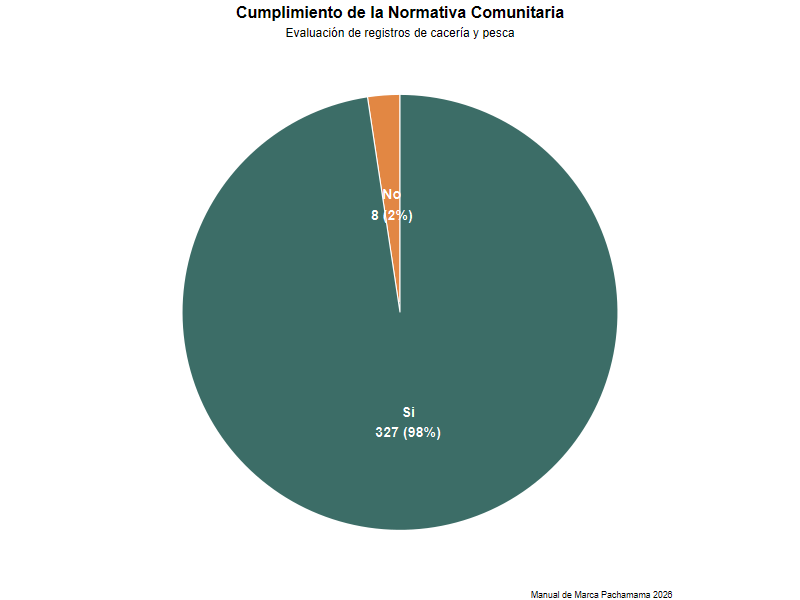

In [26]:


# 1. Preparar los datos: Calcular totales y porcentajes
resumen_normativa <- caceria_pesca %>%
  filter(!is.na(Cumplio_normativa)) %>%
  group_by(Cumplio_normativa) %>%
  summarise(Total = n(), .groups = 'drop') %>%
  mutate(
    Porcentaje = Total / sum(Total),
    Etiqueta = paste0(Cumplio_normativa, "\n", Total, " (", percent(Porcentaje, accuracy = 1), ")")
  )

# 2. Generar el Gráfico de Pastel
ggplot(resumen_normativa, aes(x = "", y = Porcentaje, fill = Cumplio_normativa)) +
  geom_bar(stat = "identity", width = 1, color = "white") +
  # Convertir a coordenadas polares para que sea un círculo
  coord_polar("y", start = 0) +
  # Añadir etiquetas internas
  geom_text(aes(label = Etiqueta), 
            position = position_stack(vjust = 0.5), 
            color = "white", fontface = "bold", size = 5) +
  # Colores: Verde para cumplimiento, Naranja/Rojo para incumplimiento
  scale_fill_manual(values = c("Si" = "#3c6d67", "No" = "#e28743")) +
  labs(
    title = "Cumplimiento de la Normativa Comunitaria",
    subtitle = "Evaluación de registros de cacería y pesca",
    caption = "Manual de Marca Pachamama 2026"
  ) +
  theme_void() + # Limpia ejes y cuadrículas para un look de pastel puro
  theme(
    legend.position = "none", # Quitamos la leyenda porque la info ya está en el pastel
    plot.title = element_text(hjust = 0.5, face = "bold", size = 16),
    plot.subtitle = element_text(hjust = 0.5, size = 12)
  )

In [27]:
caceria_pesca

    X      X_id                               X_uuid           X__version__
1   0 443814013 27beb75c-f6ed-4a64-b789-a643f6a8cad4 vaixYx97CTWbPsFJAg2ZUu
2   1 447961711 10a0e2cd-d6b5-4925-b546-3fdce9f289a5 vaixYx97CTWbPsFJAg2ZUu
3   2 448081438 5518a533-ba1f-41cf-adeb-2f1ac5edeb72 vaixYx97CTWbPsFJAg2ZUu
4   3 448081639 4d89b121-1a18-47cd-a0d7-7e385901b2ed vaixYx97CTWbPsFJAg2ZUu
5   4 448081748 3e26e05c-d877-48be-b205-6782f8c62d64 vaixYx97CTWbPsFJAg2ZUu
6   5 448081748 3e26e05c-d877-48be-b205-6782f8c62d64 vaixYx97CTWbPsFJAg2ZUu
7   6 448081748 3e26e05c-d877-48be-b205-6782f8c62d64 vaixYx97CTWbPsFJAg2ZUu
8   7 448081798 b8bb9cae-1c9e-4324-96f6-1a378eb457e6 vaixYx97CTWbPsFJAg2ZUu
9   8 448122205 d151bbb7-8d63-48d1-aa0f-f61cef942731 vaixYx97CTWbPsFJAg2ZUu
10  9 448122205 d151bbb7-8d63-48d1-aa0f-f61cef942731 vaixYx97CTWbPsFJAg2ZUu
11 10 448422878 f90e0dff-d508-43bf-ada6-e12457692a43 vaixYx97CTWbPsFJAg2ZUu
12 11 448422878 f90e0dff-d508-43bf-ada6-e12457692a43 vaixYx97CTWbPsFJAg2ZUu
13 12 448422

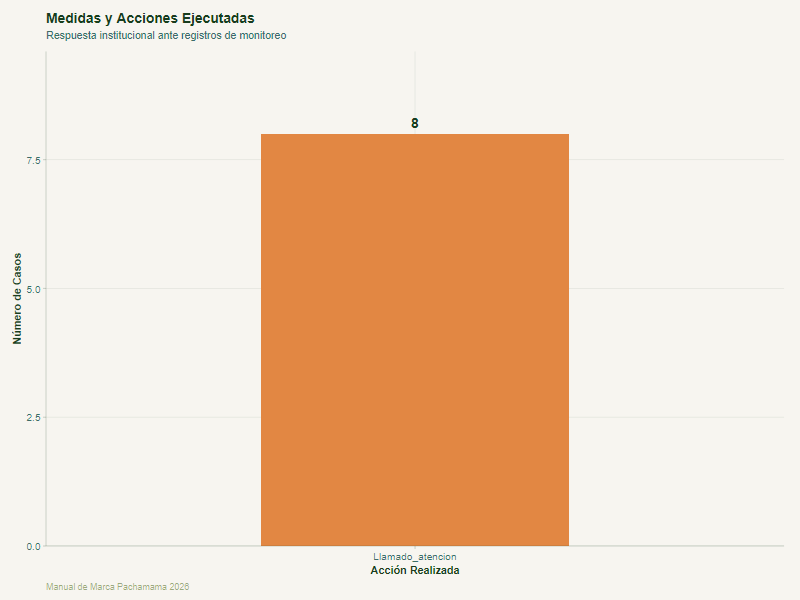

In [28]:

# 1. Preparar los datos: Contar frecuencias de acciones
resumen_acciones <- caceria_pesca %>%
  # Limpiamos NAs y espacios vacíos para que la gráfica sea útil
  filter(!is.na(Acciones_a_tomar) & Acciones_a_tomar != "" & Acciones_a_tomar != " ") %>%
  group_by(Acciones_a_tomar) %>%
  summarise(Conteo = n(), .groups = 'drop')

# 2. Generar la gráfica de barras
ggplot(resumen_acciones, aes(x = reorder(Acciones_a_tomar, -Conteo), y = Conteo, fill = Acciones_a_tomar)) +
  geom_col(width = 0.5, show.legend = FALSE) +
  # Etiquetas de valor sobre las barras
  geom_text(aes(label = Conteo), vjust = -0.5, fontface = "bold", size = 5, color = "#183d1e") +
  # Paleta Pachamama (Verdes y tonos tierra)
  scale_fill_manual(values = c("Llamado_atencion" = "#e28743", "otro" = "#3c6d67")) +
  labs(
    title = "Medidas y Acciones Ejecutadas",
    subtitle = "Respuesta institucional ante registros de monitoreo",
    x = "Acción Realizada",
    y = "Número de Casos",
    caption = "Manual de Marca Pachamama 2026"
  ) +
  # Ajuste del eje Y para visibilidad de etiquetas
  scale_y_continuous(expand = expansion(mult = c(0, 0.2))) +
  theme_pachamama()